# Linear Regression from Scratch to Scikit-Learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## 1. Data Preparation

In [5]:
x=np.array([
    [1,4, 1.5, 3.8],
    [3,6, 1.0, 3.1],
    [4,7, 0.8, 3.9],
    [5,8, 0.4, 3.4],
    [7,9, 0.2, 2.8]
])
y=np.array([45.9 ,  76.55,  92.35, 107.9 , 128.])

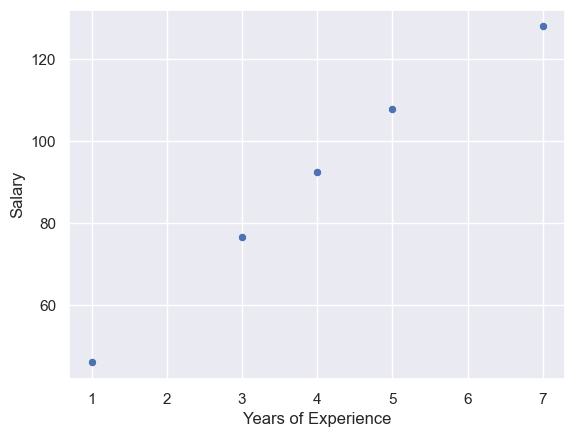

In [11]:
sns.scatterplot(x=x[:,0:1].ravel(), y=y)
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

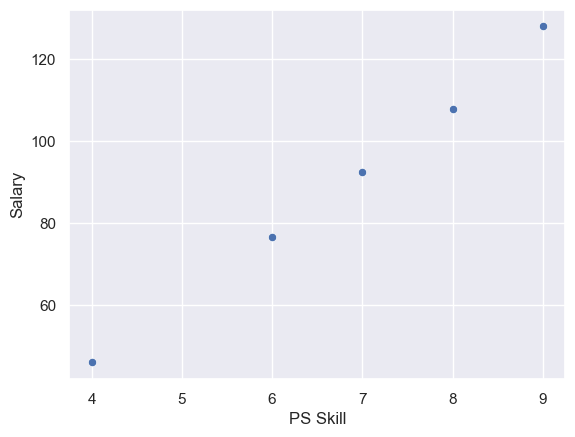

In [16]:
sns.scatterplot(x=x[:,1:2].ravel(), y=y)
plt.xlabel('PS Skill')
plt.ylabel('Salary')
plt.show()

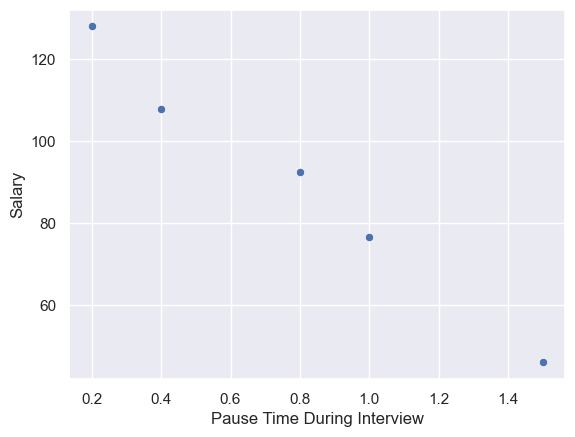

In [18]:
sns.scatterplot(x=x[:,2:3].ravel(), y=y)
plt.xlabel('Pause Time During Interview')
plt.ylabel('Salary')
plt.show()

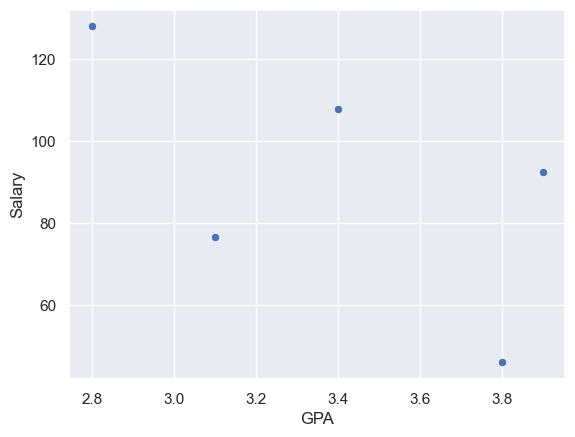

In [20]:
sns.scatterplot(x=x[:,3:4].ravel(), y=y)
plt.xlabel('GPA')
plt.ylabel('Salary')
plt.show()

In [29]:
def make_prediction(w,x,b):
    m=x.shape[0]
    prediction=np.zeros((m,))
    for i in range (m):
        prediction[i]=np.dot(w,x[i])+b
        
    return  prediction

In [31]:
m=x.shape[0]
n=x.shape[1]

w=np.ones((n,))
b=1
prediction=make_prediction(w,x,b)
print(prediction)


[11.3 14.1 16.7 17.8 20. ]


In [32]:
#cost function
def compute_cost(w,x,y,b):
    m=x.shape[0]
    cost =np.sum((make_prediction(w,x,b)-y)**2)/(2*m)
    return cost

In [34]:
W_init = np.ones((n,))
b_init = 1.0
cost=compute_cost(W_init,x,y,b_init)
print(cost)


3060.2095


In [35]:
def calculate_gradient(w,x,y,b):
    m=x.shape[0]
    n=x.shape[1]
    dw=np.zeros((n,))
    db=0
    for i in range (m):
        dw+= (make_prediction(w,x,b)[i]-y[i])*x[i]
        db+= (make_prediction(w,x,b)[i]-y[i])
    dw=dw/m
    db=db/m
    return dw,db

In [36]:
def gradient_descent(w,x,y,b,learning_rate,num_iterations):
    cost_history=[]
    for i in range (num_iterations):
        dw,db=calculate_gradient(w,x,y,b)
        w=w-learning_rate*dw
        b=b-learning_rate*db
        cost=compute_cost(w,x,y,b)
        cost_history.append(cost)
    return w,b,cost_history

# Log the status every 100 steps
w_final,b_final,cost_history=gradient_descent(W_init,x,y,b_init,learning_rate=0.01,num_iterations=1000)
print(f"Final Weights: {w_final}")

Final Weights: [ 6.87972807  8.39246896 -0.22911546  1.29890629]
